In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۷ — ماشین‌های بردار پشتیبان (SVM)
## درس ۱: مفهوم SVM برای دسته‌بندی


### اهداف یادگیری (پس از این نوت‌بوک چه چیزهایی باید بتوانید انجام دهید)

در پایان این درس، باید بتوانید:

1. **شهود هندسی** پشت SVM را توضیح دهید (ابرصفحه‌ی جداکننده + حاشیه‌ها).
2. هدف و قیود **SVM با حاشیه‌ی سخت** را استخراج کنید.
3. ایده‌ی **حاشیه‌ی نرم** را درک کنید (hinge loss، متغیرهای شُل، و نقش پارامتر $C$).
4. مفهوم **بردارهای پشتیبان** را با شرایط KKT و فرم دوگان تفسیر کنید.
5. با استفاده از **scikit-learn** یک دسته‌بند SVM عملی روی داده‌ی واقعی بسازید.
6. خطاهای رایج را رفع کنید (مقیاس‌بندی ویژگی‌ها، نامتوازنی کلاس‌ها، ابرپارامترهای کرنل).

ابتدا روی **مفهوم** (هندسه + بهینه‌سازی) تمرکز می‌کنیم و سپس سراغ تمرین‌های عملی می‌رویم.

---

### نقشه‌ی راه سریع

```mermaid
flowchart TD
  A["Data X,y"] --> B["Choose representation (scaling/encoding)"]
  B --> C["Pick SVM family: linear / kernel"]
  C --> D["Train: maximize margin (soft/hard)"]
  D --> E["Inspect: support vectors, margin, errors"]
  E --> F["Evaluate: confusion matrix, ROC, CV"]
  F --> G["Deploy: pipeline + saved model"]
```



## ۱) دسته‌بندی خطی به‌عنوان یک مسئله‌ی هندسی

یک **دسته‌بند خطی** در $\mathbb{R}^d$ از یک ابرصفحه استفاده می‌کند:

$$
f(x) = w^\top x + b
$$

و پیش‌بینی می‌کند:

$$
\hat{y} = \text{sign}(f(x)) \in \{-1,+1\}.
$$

مجموعه‌ی $\{x : w^\top x + b = 0\}$ **مرز تصمیم** است. یک سمت آن $+1$ و سمت دیگر $-1$ پیش‌بینی می‌شود.

### ۱.۱ حاشیه‌ی تابعی در برابر حاشیه‌ی هندسی

فرض کنید برچسب‌ها $y_i \in \{-1,+1\}$ باشند. برای هر نقطه‌ی آموزشی $(x_i,y_i)$، **حاشیه‌ی تابعی** را تعریف می‌کنیم:

$$
\gamma_i^{(f)} = y_i(w^\top x_i + b).
$$

اگر $\gamma_i^{(f)} > 0$ باشد، نقطه درست طبقه‌بندی شده است. اما $\gamma_i^{(f)}$ به *مقیاس* $(w,b)$ وابسته است:

- اگر $(w,b)$ را در هر $c>0$ ضرب کنیم، پیش‌بینی‌ها تغییر نمی‌کنند (علامت ثابت می‌ماند)،
- ولی $\gamma_i^{(f)}$ در $c$ ضرب می‌شود.

پس به حاشیه‌ای نیاز داریم که **نسبت به مقیاس ناوردا** باشد.

### ۱.۲ فاصله‌ی یک نقطه تا ابرصفحه

فاصله‌ی (با علامت) نقطه‌ی $x$ تا ابرصفحه‌ی $w^\top x + b = 0$ برابر است با:

$$
\text{dist}(x,\mathcal{H}) = \frac{w^\top x + b}{\|w\|_2}.
$$

بنابراین **حاشیه‌ی هندسی** نقطه‌ی $(x_i,y_i)$ برابر است با:

$$
\gamma_i = y_i \frac{w^\top x_i + b}{\|w\|_2}.
$$

این مقدار نسبت به مقیاس ناورداست: اگر $(w,b)\mapsto (cw,cb)$، صورت و مخرج هر دو در $c$ ضرب می‌شوند و $\gamma_i$ ثابت می‌ماند.

### ۱.۳ اصل SVM (بیشینه‌کردن حاشیه)

SVM ابرصفحه‌ای را انتخاب می‌کند که **کمینه‌ی حاشیه‌ی هندسی** روی همه‌ی نقاط آموزشی را بیشینه کند:

$$
\max_{w,b}\ \min_i\ \gamma_i
\quad \text{s.t. } y_i(w^\top x_i + b) > 0 \ \forall i.
$$

این کار مرز تصمیم را از همه‌ی نقاط دور می‌کند و معمولاً به تعمیم بهتر کمک می‌کند.

---

**شهود کلیدی:** این دسته‌بند عمدتاً توسط «نزدیک‌ترین» نقاط به مرز تصمیم تعیین می‌شود؛ این نقاط همان **بردارهای پشتیبان** هستند.



## ۲) SVM با حاشیه‌ی سخت (حالت جداسازی‌پذیر خطی)

فرض کنید داده‌ها کاملاً جداسازی‌پذیر هستند. می‌توانیم مقیاس را با این نرمال‌سازی ثابت کنیم:

$$
y_i(w^\top x_i + b) \ge 1,\quad i=1,\dots,n.
$$

چرا «۱»؟ چون هر ثابت مثبت دیگری هم قابل استفاده است؛ انتخاب $1$ فقط یک نرمال‌سازیِ راحت است.

### ۲.۱ عرض حاشیه

دو ابرصفحه‌ی «حاشیه» عبارت‌اند از:

$$
w^\top x + b = 1,\qquad w^\top x + b = -1.
$$

فاصله‌ی بین این دو برابر است با:

$$
\frac{2}{\|w\|_2}.
$$

**طرح اثبات:** فاصله از $w^\top x + b=0$ تا $w^\top x + b=1$ برابر $1/\|w\|_2$ است و برای سمت دیگر هم همین‌طور؛ پس مجموع $2/\|w\|_2$ می‌شود.

پس بیشینه‌کردن حاشیه معادل کمینه‌کردن $\|w\|_2$ است. فرمول استاندارد SVM با حاشیه‌ی سخت:

$$
\min_{w,b}\ \frac{1}{2}\|w\|_2^2
\quad \text{s.t. } y_i(w^\top x_i + b) \ge 1,\ \forall i.
$$

### ۲.۲ کوژبودن (چرا این مسئله خوب است)

- تابع هدف $\frac{1}{2}\|w\|_2^2$ نسبت به $w$ **کوژ** است.
- قیود نسبت به $(w,b)$ **خطی** هستند.

پس این یک **مسئله‌ی درجه‌دو کوژ** است: هر بهینه‌ی محلی، بهینه‌ی سراسری است.

### ۲.۳ بردارهای پشتیبان به‌صورت خودکار ظاهر می‌شوند

در جواب بهینه، بسیاری از نقاط شرط زیر را دارند:

$$
y_i(w^\top x_i + b) > 1
$$

و از مرز تصمیم دورند. فقط نقاطی که روی حاشیه قرار می‌گیرند شرط زیر را ارضا می‌کنند:

$$
y_i(w^\top x_i + b) = 1
$$

و این‌ها همان **بردارهای پشتیبان** هستند که راه‌حل بیشینه‌حاشیه را «پشتیبانی» می‌کنند.

---

> در عمل داده‌ها به‌ندرت کاملاً جداسازی‌پذیر هستند (نویز، هم‌پوشانی). بنابراین به SVM با حاشیه‌ی نرم نیاز داریم.



## ۳) SVM با حاشیه‌ی نرم (حالت واقع‌گرایانه)

وقتی داده‌ها هم‌پوشانی دارند یا نویز وجود دارد، قیود سخت $y_i(w^\top x_i + b)\ge 1$ ممکن است شدنی نباشند.
در حاشیه‌ی نرم، **متغیرهای شُل** $\xi_i \ge 0$ معرفی می‌شوند:

$$
y_i(w^\top x_i + b) \ge 1 - \xi_i,\quad \xi_i \ge 0.
$$

تفسیر:
- $\xi_i = 0$: نقطه درست طبقه‌بندی شده و بیرون/روی حاشیه است.
- $0<\xi_i<1$: درست طبقه‌بندی شده ولی داخل حاشیه قرار دارد.
- $\xi_i \ge 1$: بدطبقه‌بندی شده است (سمت اشتباه).

مسئله‌ی بهینه‌سازی:

$$
\min_{w,b,\xi}\ \frac{1}{2}\|w\|_2^2 + C \sum_{i=1}^n \xi_i
\quad \text{s.t. } y_i(w^\top x_i + b) \ge 1-\xi_i,\ \xi_i\ge 0.
$$

### ۳.۱ نقش $C$

- $C$ بزرگ: جریمه‌ی شدید برای نقض قیود → **خطای آموزش کمتر**، احتمالاً حاشیه کوچک‌تر (خطر بیش‌برازش).
- $C$ کوچک: اجازه‌ی نقض بیشتر → **حاشیه بزرگ‌تر**، احتمالاً خطای آموزش بیشتر (گاهی تعمیم بهتر).

پس $C$ یک پارامتر **منظم‌سازی/تجارت‌آف** است.

### ۳.۲ دیدگاه hinge loss

می‌توان حاشیه‌ی نرم را به‌صورت کمینه‌سازی یک ریسک تجربی منظم‌شده با **hinge loss** نوشت:

$$
\ell_{\text{hinge}}(y,f(x)) = \max(0, 1 - y f(x)).
$$

و در نتیجه:

$$
\min_{w,b}\ \frac{1}{2}\|w\|_2^2 + C \sum_{i=1}^n \max(0, 1 - y_i(w^\top x_i + b)).
$$

این فرم برای موارد زیر بسیار مفید است:
- اتصال SVM به سایر اهداف یادگیری ماشین،
- طراحی الگوریتم‌های پیاده‌سازی از صفر (زیرگرادیان، SGD)،
- درک شهود مقاومت: hinge loss پاداش بزرگی برای حاشیه‌های خیلی بزرگ نمی‌دهد.



## ۴) دیدگاه دوگان، کرنل‌ها و بردارهای پشتیبان (پیش‌نمایش مفهومی)

حتی اگر SVM را با فرم پرایمال آموزش دهید، فرم **دوگان** نشان می‌دهد چرا SVM قدرتمند است.

### ۴.۱ لاگرانژ (حاشیه‌ی سخت)
برای حاشیه‌ی سخت، ضرایب لاگرانژ $\alpha_i \ge 0$ را تعریف کنید و لاگرانژین را بسازید:

$$
\mathcal{L}(w,b,\alpha) = \frac{1}{2}\|w\|_2^2 - \sum_{i=1}^n \alpha_i\big(y_i(w^\top x_i + b) - 1\big).
$$

با صفر کردن مشتق‌ها (ایستایی):

1. $\frac{\partial \mathcal{L}}{\partial w}=0 \Rightarrow w = \sum_{i=1}^n \alpha_i y_i x_i$
2. $\frac{\partial \mathcal{L}}{\partial b}=0 \Rightarrow \sum_{i=1}^n \alpha_i y_i = 0$

با جایگذاری، دوگان به‌دست می‌آید (بیشینه‌سازی نسبت به $\alpha$):

$$
\max_{\alpha}\ \sum_{i=1}^n \alpha_i - \frac{1}{2}\sum_{i=1}^n\sum_{j=1}^n \alpha_i\alpha_j y_i y_j\, x_i^\top x_j
\quad \text{s.t. } \alpha_i \ge 0,\ \sum_i \alpha_i y_i = 0.
$$

### ۴.۲ بردارهای پشتیبان با KKT
شرط مکمل‌بودن KKT می‌گوید:

$$
\alpha_i \big(y_i(w^\top x_i + b) - 1\big) = 0.
$$

پس:
- اگر نقطه روی حاشیه نباشد ($y_i(w^\top x_i + b) > 1$)، آنگاه $\alpha_i = 0$.
- فقط نقاط حاشیه $\alpha_i>0$ دارند → آن‌ها همان **بردارهای پشتیبان** هستند.

### ۴.۳ ترفند کرنل (ایده)
توجه کنید فرم دوگان فقط به ضرب داخلی‌ها $x_i^\top x_j$ وابسته است. اگر داده را به فضای ویژگی $\phi(x)$ ببریم، ضرب داخلی تبدیل می‌شود به:

$$
\phi(x_i)^\top \phi(x_j) = K(x_i, x_j)
$$

بدون اینکه لازم باشد $\phi$ را صراحتاً حساب کنیم. در نتیجه تابع تصمیم:

$$
f(x) = \sum_{i=1}^n \alpha_i y_i K(x_i, x) + b.
$$

**درک مفهومی:** SVM می‌تواند مرزهای غیرخطی یاد بگیرد و در عین حال یک مسئله‌ی بهینه‌سازی کوژ باقی بماند.

> در درس بعدی به کرنل‌ها عمیق‌تر می‌پردازیم. اینجا فقط تصویر کلی را نگه می‌داریم.


## ۵) تمرین عملی: دسته‌بندی با SVM روی یک دیتاست واقعی

In [2]:
# Core scientific stack
import numpy as np
import pandas as pd

# Modeling + evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.decomposition import PCA

# Plotting
import matplotlib.pyplot as plt

np.random.seed(42)



### ۵.۱ بارگذاری دیتاست مطابق ساختار ریپازیتوری

در این ریپازیتوری، دیتاست‌های دسته‌بندی در مسیر زیر قرار دارند:

- `../../../Datasets/Classification/...`

برای این درس از **iris.csv** (چندکلاسه) استفاده می‌کنیم، اما برای نمایش بهترِ مفهوم حاشیه، یک نسخه‌ی **دودویی** هم می‌سازیم.

> اگر این مسیر در محیط فعلی شما در دسترس نباشد (مثلاً نوت‌بوک را خارج از ریپو اجرا کنید)، کد به دیتاست Iris داخلی scikit-learn برمی‌گردد.


In [3]:
# Load iris from repo path (preferred), otherwise fallback to sklearn
path = "../../../Datasets/Classification/iris.csv"

try:
    df = pd.read_csv(path)
    # Expected columns: sepal_length,sepal_width,petal_length,petal_width,classification
    if "classification" not in df.columns:
        raise ValueError("Expected a 'classification' column in iris.csv")
except Exception as e:
    from sklearn.datasets import load_iris
    iris = load_iris(as_frame=True)
    df = iris.frame.copy()
    df["classification"] = df["target"].map(dict(enumerate(iris.target_names)))
    df = df.drop(columns=["target"])

print(df.head())
print("\nClass distribution:")
print(df["classification"].value_counts())


   sepal_length  sepal_width  petal_length  petal_width classification
0           5.4          3.7           1.5          0.2    Iris-setosa
1           4.8          3.4           1.6          0.2    Iris-setosa
2           4.8          3.0           1.4          0.1    Iris-setosa
3           4.3          3.0           1.1          0.1    Iris-setosa
4           5.8          4.0           1.2          0.2    Iris-setosa

Class distribution:
classification
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64



### ۵.۲ ساخت یک مسئله‌ی دودویی (Setosa در برابر غیرِ Setosa)

برای نمایش هندسی و حاشیه‌ها، دودویی‌کردن مسئله ساده‌تر است.
نگاشت می‌کنیم:

- `Iris-setosa` $\rightarrow +1$
- سایر کلاس‌ها $\rightarrow -1$

سپس یک SVM خطی آموزش می‌دهیم.


In [4]:
# Binary labels: +1 for setosa, -1 otherwise
y = np.where(df["classification"].astype(str).str.contains("setosa", case=False), 1, -1)
X = df.drop(columns=["classification"]).to_numpy(dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# A good default for SVM: scale features (important!)
linear_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear", C=1.0))
])

linear_svm.fit(X_train, y_train)

y_pred = linear_svm.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        13

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38




### ۵.۳ چرا مقیاس‌بندی مهم است؟ (یک آزمایش سریع)

SVM بر اساس ضرب داخلی/فاصله‌ها کار می‌کند. اگر یک ویژگی مقیاس عددی خیلی بزرگ‌تری داشته باشد،
می‌تواند هندسه‌ی حاشیه را تحت‌تأثیر قرار دهد. در اینجا عملکرد را با و بدون مقیاس‌بندی مقایسه می‌کنیم.


In [5]:
# Without scaling
svm_no_scaling = SVC(kernel="linear", C=1.0)
svm_no_scaling.fit(X_train, y_train)
pred_no_scaling = svm_no_scaling.predict(X_test)

# With scaling (already trained above)
pred_scaled = y_pred

print("Accuracy without scaling:", accuracy_score(y_test, pred_no_scaling))
print("Accuracy with scaling:", accuracy_score(y_test, pred_scaled))


Accuracy without scaling: 1.0
Accuracy with scaling: 1.0



### ۵.۴ بررسی بردارهای پشتیبان و (تقریب) عرض حاشیه

برای SVM **خطی**، عرض حاشیه تقریباً $2/\|w\|_2$ در فضای ویژگیِ مقیاس‌بندی‌شده است.
در `SVC(kernel="linear")` پس از آموزش می‌توان به `coef_` دسترسی داشت.

کارهایی که انجام می‌دهیم:

1. استخراج $w$ از مدل آموزش‌دیده،
2. محاسبه‌ی $\|w\|_2$،
3. تخمین عرض حاشیه،
4. شمارش بردارهای پشتیبان.


In [6]:
# Extract the trained SVC
svc = linear_svm.named_steps["clf"]
scaler = linear_svm.named_steps["scaler"]

w = svc.coef_.ravel()  # in scaled space
w_norm = np.linalg.norm(w)
margin_width = 2.0 / (w_norm + 1e-12)

print("||w||_2 (scaled space):", w_norm)
print("Estimated margin width (scaled space):", margin_width)
print("Number of support vectors:", svc.support_.shape[0])


||w||_2 (scaled space): 1.0861859273438574
Estimated margin width (scaled space): 1.8413053876410719
Number of support vectors: 3



### ۵.۵ نمایش مرز تصمیم در ۲ بعد

فضای ویژگی ما ۴بعدی است؛ برای نمایش، با PCA آن را به ۲بعد کاهش می‌دهیم (صرفاً برای visualization).
سپس در فضای ۲بعد یک SVM خطی آموزش می‌دهیم و مرز تصمیم و نوارهای حاشیه را رسم می‌کنیم.

> توجه: این فقط یک ترفند نمایشی است. مدل اصلی بالا از هر ۴ ویژگی استفاده می‌کند.


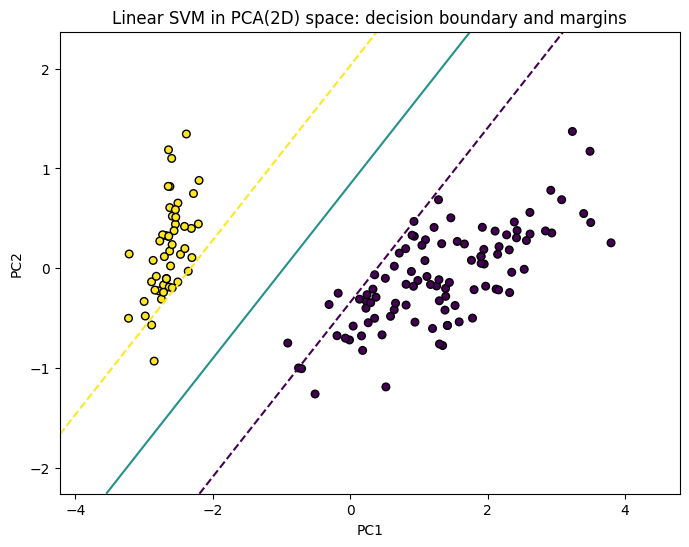

In [7]:
# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.25, random_state=42, stratify=y
)

svm2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear", C=1.0))
])

svm2.fit(X2_train, y2_train)

# Create a mesh grid
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

# Decision function values for contouring
Z = svm2.decision_function(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=["--", "-", "--"])
plt.scatter(X2[:, 0], X2[:, 1], c=(y==1), s=30, edgecolors="k")
plt.title("Linear SVM in PCA(2D) space: decision boundary and margins")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



## ۶) مقایسه‌ی SVM خطی و کرنلی (در سطح بالا)

SVM خطی $f(x) = w^\top x + b$ را یاد می‌گیرد. اگر کلاس‌ها خطی جداسازی‌پذیر نباشند،
می‌توانیم از **کرنل** برای مدل‌کردن مرزهای غیرخطی استفاده کنیم.

کرنل‌های رایج:
- **Linear:** $K(x,z)=x^\top z$
- **Polynomial:** $K(x,z)=(\gamma x^\top z + r)^d$
- **RBF (Gaussian):** $K(x,z)=\exp(-\gamma\|x-z\|_2^2)$

در ادامه روی همین مسئله‌ی دودویی، این‌ها را با یک grid search ساده مقایسه می‌کنیم.

> عنوان‌ها/برچسب‌های نمودارها انگلیسی باقی می‌مانند (طبق قانون نوت‌بوک فارسی).


In [8]:
# Compare kernels using GridSearchCV (pipeline includes scaling)
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC())
])

param_grid = [
    {"clf__kernel": ["linear"], "clf__C": [0.1, 1, 10]},
    {"clf__kernel": ["poly"], "clf__C": [0.1, 1, 10], "clf__degree": [2, 3, 4], "clf__gamma": ["scale", "auto"]},
    {"clf__kernel": ["rbf"], "clf__C": [0.1, 1, 10], "clf__gamma": ["scale", "auto"]},
]

gs = GridSearchCV(pipe, param_grid, scoring="accuracy", cv=5, n_jobs=-1)
gs.fit(X, y)

print("Best params:", gs.best_params_)
print("Best CV accuracy:", gs.best_score_)


Best params: {'clf__C': 0.1, 'clf__kernel': 'linear'}
Best CV accuracy: 1.0



## ۷) SVM چندکلاسه (به‌صورت کوتاه)

در مسائل واقعی معمولاً بیش از دو کلاس داریم.
SVM کلاسیک دودویی است، اما چندکلاسه را می‌توان با راهبردهایی مثل موارد زیر حل کرد:

- **One-vs-Rest (OvR):** آموزش $K$ دسته‌بند دودویی (کلاس $k$ در برابر بقیه).
- **One-vs-One (OvO):** آموزش $\frac{K(K-1)}{2}$ دسته‌بند (جفت‌به‌جفت).

در `scikit-learn`:
- `SVC` به‌صورت داخلی از OvO برای چندکلاسه استفاده می‌کند.
- `LinearSVC` از OvR استفاده می‌کند (و برای داده‌های بزرگ سریع‌تر است).

در ادامه یک SVM چندکلاسه روی دیتاست Iris (۳ کلاس) آموزش می‌دهیم و خروجی را بررسی می‌کنیم.


In [9]:
# Multi-class using the original labels (from the CSV / fallback)
# We'll re-create y_mc as strings to avoid assumptions about label encoding
y_mc = df["classification"].astype(str).to_numpy()
X_mc = df.drop(columns=["classification"]).to_numpy(dtype=float)

Xtr, Xte, ytr, yte = train_test_split(X_mc, y_mc, test_size=0.25, random_state=42, stratify=y_mc)

mc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

mc_model.fit(Xtr, ytr)
pred = mc_model.predict(Xte)

print("Accuracy:", accuracy_score(yte, pred))
print(classification_report(yte, pred))


Accuracy: 0.9473684210526315
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        12
Iris-versicolor       0.92      0.92      0.92        13
 Iris-virginica       0.92      0.92      0.92        13

       accuracy                           0.95        38
      macro avg       0.95      0.95      0.95        38
   weighted avg       0.95      0.95      0.95        38




## ۸) دیدگاه پیاده‌سازی از صفر: SGD برای hinge-loss (سبک Pegasos)

برای تقویت شهود، یک یادگیرنده‌ی SVM خطی ساده با **زیرگرادیان** روی هدف زیر پیاده‌سازی می‌کنیم:

$$
\min_w\ \frac{\lambda}{2}\|w\|_2^2 + \frac{1}{n}\sum_{i=1}^n \max(0, 1 - y_i w^\top x_i).
$$

این هدف از نظر ایده به SVM حاشیه‌ی نرم نزدیک است.
در اینجا $\lambda$ منظم‌سازی را کنترل می‌کند (و بسته به قرارداد مقیاس‌بندی، با $C$ مرتبط است).

### ۸.۱ زیرگرادیان hinge loss

برای نمونه‌ی $(x_i,y_i)$، $m_i = y_i w^\top x_i$ را تعریف کنید.
آنگاه:

- اگر $m_i \ge 1$، hinge loss صفر است و زیرگرادیان نسبت به $w$ برابر $0$ است.
- اگر $m_i < 1$، hinge loss برابر $1-m_i$ و زیرگرادیان برابر $-y_i x_i$ است.

پس یک گام زیرگرادیان:

$$
w \leftarrow w - \eta\Big(\lambda w + g_i\Big)
$$

که در آن

$$
g_i =
\begin{cases}
0 & m_i \ge 1\\
-y_i x_i & m_i < 1
\end{cases}
$$

در ادامه روی همان مسئله‌ی دودویی Iris (با مقیاس‌بندی) آموزش می‌دهیم و دقت را مقایسه می‌کنیم.


In [10]:
def hinge_svm_sgd(X, y, lam=1e-3, lr=0.1, epochs=50, seed=42):
    """Linear SVM via hinge-loss subgradient descent.
    X: (n,d) numpy array (assume already scaled)
    y: (n,) in {-1,+1}
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape
    w = np.zeros(d)

    for ep in range(epochs):
        idx = rng.permutation(n)
        for i in idx:
            xi = X[i]
            yi = y[i]
            margin = yi * np.dot(w, xi)
            if margin >= 1.0:
                grad = lam * w
            else:
                grad = lam * w - yi * xi
            w = w - lr * grad
        # Optional: learning rate decay
        lr *= 0.98
    return w

# Scale features first (same reason as earlier)
sc = StandardScaler()
X_scaled = sc.fit_transform(X_train)
X_scaled_test = sc.transform(X_test)

w_hat = hinge_svm_sgd(X_scaled, y_train, lam=1e-3, lr=0.1, epochs=80)

# Predict: sign(w^T x) (no bias term in this simple demo; you can add it by augmenting X with 1s)
pred_train = np.sign(X_scaled @ w_hat)
pred_test = np.sign(X_scaled_test @ w_hat)

# Replace zeros (rare) with +1
pred_test[pred_test == 0] = 1
pred_train[pred_train == 0] = 1

print("From-scratch hinge-SVM train accuracy:", accuracy_score(y_train, pred_train))
print("From-scratch hinge-SVM test accuracy:", accuracy_score(y_test, pred_test))


From-scratch hinge-SVM train accuracy: 1.0
From-scratch hinge-SVM test accuracy: 1.0



## ۹) تمرین‌های کوتاه (به‌همراه پاسخ)

این تمرین‌ها برای ساخت سریع شهود طراحی شده‌اند.

### تمرین ۱ — حاشیه در برابر خطا
کد زیر را برای مقادیر مختلف $C \in \{0.01, 0.1, 1, 10, 100\}$ اجرا کنید.
موارد زیر را مشاهده کنید:
- تعداد بردارهای پشتیبان،
- دقت روی داده‌ی آموزش،
- دقت روی داده‌ی آزمون،
- تخمین عرض حاشیه $2/\|w\|_2$ (برای کرنل خطی).

**سؤال:** با افزایش $C$ انتظار دارید حاشیه افزایش یابد یا کاهش؟ چرا؟

### تمرین ۲ — اثر کرنل
`kernel="linear"` را به `kernel="rbf"` تغییر دهید و `gamma` را تنظیم کنید.
**سؤال:** اگر `gamma` خیلی بزرگ باشد چه اتفاقی می‌افتد؟ (راهنما: مرز تصمیم خیلی «پیچ‌وتاب‌دار» می‌شود).

### تمرین ۳ — نامتوازنی (مفهومی)
فرض کنید کلاس مثبت خیلی کم است (مثل کشف تقلب).
**سؤال:** چرا دقت (accuracy) می‌تواند گمراه‌کننده باشد و چه معیارهای دیگری را گزارش می‌کنید؟

---

### پاسخ‌ها (بحث)

**تمرین ۱ (روند مورد انتظار):** $C$ بزرگ‌تر نقض قیود را شدیدتر جریمه می‌کند، بنابراین بهینه‌ساز ممکن است برای کاهش خطای آموزش، حاشیه‌ی کوچک‌تری را بپذیرد. پس افزایش $C$ معمولاً باعث **کاهش** عرض حاشیه می‌شود (هرچند لزوماً در همه‌ی دیتاست‌ها کاملاً یکنواخت نیست).

**تمرین ۲ (gamma خیلی بزرگ):** هر نقطه فقط ناحیه‌ی نفوذ بسیار محلی دارد و مرز تصمیم بیش‌برازش می‌کند؛ ممکن است دقت آموزش بالا باشد ولی تعمیم ضعیف شود.

**تمرین ۳ (نامتوازنی):** با پیش‌بینی دائمی کلاس اکثریت می‌توان accuracy بالایی گرفت. معیارهای بهتر: precision/recall، F1، ROC-AUC، PR-AUC، balanced accuracy و تحلیل هزینه/فایده.


In [11]:
def run_linear_svm_for_C(C):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", C=C))
    ])
    model.fit(X_train, y_train)
    svc_local = model.named_steps["clf"]
    w = svc_local.coef_.ravel()
    w_norm = np.linalg.norm(w)
    margin_width = 2.0 / (w_norm + 1e-12)
    ytr_pred = model.predict(X_train)
    yte_pred = model.predict(X_test)
    return {
        "C": C,
        "n_support": int(svc_local.support_.shape[0]),
        "train_acc": float(accuracy_score(y_train, ytr_pred)),
        "test_acc": float(accuracy_score(y_test, yte_pred)),
        "margin_width_scaled": float(margin_width),
    }

results = [run_linear_svm_for_C(C) for C in [0.01, 0.1, 1, 10, 100]]
pd.DataFrame(results)


,C,n_support,train_acc,test_acc,margin_width_scaled
0,0.01,55,1.0,1.0,3.033404
1,0.10,11,1.0,1.0,2.143539
2,1.00,3,1.0,1.0,1.841305
3,10.00,3,1.0,1.0,1.841305
4,100.00,3,1.0,1.0,1.841305



## ۱۰) جمع‌بندی (نکات کلیدی)

- SVM مرز تصمیمی را انتخاب می‌کند که **حاشیه را بیشینه** کند (فاصله تا نزدیک‌ترین نقاط).
- حاشیه‌ی سخت جداسازی کامل را فرض می‌کند؛ حاشیه‌ی نرم با متغیرهای شُل و پارامتر $C$ تجارت‌آف ایجاد می‌کند.
- فقط زیرمجموعه‌ای از نقاط ( **بردارهای پشتیبان** ) مدل را تعیین می‌کنند.
- فرم دوگان نشان می‌دهد چرا کرنل‌ها جواب می‌دهند: فقط ضرب داخلی لازم است که با $K(x,z)$ جایگزین می‌شود.
- در عمل: **مقیاس‌بندی** حیاتی است و ابرپارامترها ($C$، نوع کرنل، $\gamma$، درجه) باید با cross-validation تنظیم شوند.

در درس بعدی، **کرنل‌ها** و ترفند کرنل را عمیق‌تر بررسی می‌کنیم.
